# SQL Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("events.csv")

print("Dataset Shape:", df.shape)
display(df.head())
df.info()

Dataset Shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [ ]:
import sqlite3

# Create a SQLite database
conn = sqlite3.connect('ecommerce.db')

# Load the Pandas dataframe into an SQL table
df.to_sql(
    'events',
    conn,
    if_exists='replace',
    index=False
)

print("Events data successfully loaded into SQLite!")

Events data successfully loaded into SQLite!


In [ ]:
query = """
SELECT *
FROM events
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,None
1,1433224214164,992329,view,248676,None
2,1433221999827,111016,view,318965,None
3,1433221955914,483717,view,253185,None
4,1433221337106,951259,view,367447,None


Event Overview

In [ ]:
query = """
SELECT
    event,
    COUNT(*) AS total_events,
    COUNT(DISTINCT visitorid) AS unique_users
FROM events
GROUP BY event
ORDER BY total_events DESC;
"""

event_overview = pd.read_sql_query(query, conn)

event_overview

,event,total_events,unique_users
0,view,2664312,1404179
1,addtocart,69332,37722
2,transaction,22457,11719


Funnel Analysis

In [ ]:
query = """
SELECT
    COUNT(DISTINCT CASE
        WHEN event = 'view'
        THEN visitorid
    END) AS view_users,

    COUNT(DISTINCT CASE
        WHEN event = 'addtocart'
        THEN visitorid
    END) AS cart_users,

    COUNT(DISTINCT CASE
        WHEN event = 'transaction'
        THEN visitorid
    END) AS transaction_users

FROM events;
"""

sql_funnel = pd.read_sql_query(query, conn)

sql_funnel

,view_users,cart_users,transaction_users
0,1404179,37722,11719


Conversion Rates and Drop-off Analysis.

In [ ]:
query = """
WITH funnel AS (
    SELECT
        COUNT(DISTINCT CASE
            WHEN event = 'view'
            THEN visitorid
        END) AS view_users,

        COUNT(DISTINCT CASE
            WHEN event = 'addtocart'
            THEN visitorid
        END) AS cart_users,

        COUNT(DISTINCT CASE
            WHEN event = 'transaction'
            THEN visitorid
        END) AS transaction_users

    FROM events
)

SELECT
    view_users,
    cart_users,
    transaction_users,

    ROUND(
        100.0 * cart_users / view_users,
        2
    ) AS view_to_cart_conversion,

    ROUND(
        100.0 * transaction_users / cart_users,
        2
    ) AS cart_to_transaction_conversion,

    ROUND(
        100.0 * transaction_users / view_users,
        2
    ) AS overall_conversion

FROM funnel;
"""

sql_conversion = pd.read_sql_query(query, conn)

sql_conversion

,view_users,cart_users,transaction_users,view_to_cart_conversion,cart_to_transaction_conversion,overall_conversion
0,1404179,37722,11719,2.69,31.07,0.83


Cart Abandonment Analysis

In [ ]:
query = """
WITH cart_users AS (
    SELECT DISTINCT visitorid
    FROM events
    WHERE event = 'addtocart'
),

purchase_users AS (
    SELECT DISTINCT visitorid
    FROM events
    WHERE event = 'transaction'
)

SELECT
    COUNT(*) AS abandoned_cart_users
FROM cart_users
WHERE visitorid NOT IN (
    SELECT visitorid
    FROM purchase_users
);
"""

sql_cart_abandonment = pd.read_sql_query(query, conn)

sql_cart_abandonment

,abandoned_cart_users
0,27146


Cart Abandonment Rate

In [ ]:
query = """
WITH cart_users AS (
    SELECT DISTINCT visitorid
    FROM events
    WHERE event = 'addtocart'
),

purchase_users AS (
    SELECT DISTINCT visitorid
    FROM events
    WHERE event = 'transaction'
),

abandoned_users AS (
    SELECT visitorid
    FROM cart_users
    WHERE visitorid NOT IN (
        SELECT visitorid
        FROM purchase_users
    )
)

SELECT
    (SELECT COUNT(*) FROM cart_users) AS total_cart_users,

    (SELECT COUNT(*) FROM abandoned_users) AS abandoned_cart_users,

    ROUND(
        100.0 *
        (SELECT COUNT(*) FROM abandoned_users) /
        (SELECT COUNT(*) FROM cart_users),
        2
    ) AS cart_abandonment_rate;
"""

sql_cart_abandonment_rate = pd.read_sql_query(query, conn)

sql_cart_abandonment_rate

,total_cart_users,abandoned_cart_users,cart_abandonment_rate
0,37722,27146,71.96


User Segmentation.

In [ ]:
query = """
WITH user_transactions AS (
    SELECT
        visitorid,
        COUNT(*) AS transaction_count
    FROM events
    WHERE event = 'transaction'
    GROUP BY visitorid
),

all_users AS (
    SELECT DISTINCT visitorid
    FROM events
),

user_segments AS (
    SELECT
        a.visitorid,

        CASE
            WHEN u.transaction_count IS NULL
                THEN 'Non-Buyer'

            WHEN u.transaction_count = 1
                THEN 'One-Time Buyer'

            WHEN u.transaction_count > 1
                THEN 'Repeat Buyer'
        END AS user_segment

    FROM all_users a

    LEFT JOIN user_transactions u
        ON a.visitorid = u.visitorid
)

SELECT
    user_segment,
    COUNT(*) AS number_of_users

FROM user_segments

GROUP BY user_segment

ORDER BY number_of_users DESC;
"""

sql_user_segmentation = pd.read_sql_query(query, conn)

sql_user_segmentation

,user_segment,number_of_users
0,Non-Buyer,1395861
1,One-Time Buyer,9143
2,Repeat Buyer,2576


Product Performance Analysis


In [ ]:
query = """
WITH product_metrics AS (
    SELECT
        itemid,

        SUM(
            CASE
                WHEN event = 'view' THEN 1
                ELSE 0
            END
        ) AS views,

        SUM(
            CASE
                WHEN event = 'addtocart' THEN 1
                ELSE 0
            END
        ) AS add_to_cart,

        SUM(
            CASE
                WHEN event = 'transaction' THEN 1
                ELSE 0
            END
        ) AS transactions

    FROM events

    WHERE itemid IS NOT NULL

    GROUP BY itemid
)

SELECT
    itemid,
    views,
    add_to_cart,
    transactions,

    ROUND(
        100.0 * add_to_cart / NULLIF(views, 0),
        2
    ) AS view_to_cart_conversion,

    ROUND(
        100.0 * transactions / NULLIF(views, 0),
        2
    ) AS view_to_purchase_conversion

FROM product_metrics

ORDER BY transactions DESC;
"""

sql_product_performance = pd.read_sql_query(query, conn)

sql_product_performance.head(10)

,itemid,views,add_to_cart,transactions,view_to_cart_conversion,view_to_purchase_conversion
0,461686,2539,306,133,12.05,5.24
1,119736,752,44,97,5.85,12.90
2,213834,293,17,92,5.80,31.40
3,7943,1346,97,46,7.21,3.42
4,312728,947,162,46,17.11,4.86
5,445351,939,89,45,9.48,4.79
6,48030,986,95,41,9.63,4.16
7,248455,575,52,38,9.04,6.61
8,420960,796,60,38,7.54,4.77
9,17478,631,72,37,11.41,5.86


High-Interest but Low-Conversion Products

In [ ]:
query = """
WITH product_metrics AS (
    SELECT
        itemid,

        SUM(
            CASE
                WHEN event = 'view' THEN 1
                ELSE 0
            END
        ) AS views,

        SUM(
            CASE
                WHEN event = 'transaction' THEN 1
                ELSE 0
            END
        ) AS transactions

    FROM events

    WHERE itemid IS NOT NULL

    GROUP BY itemid
),

product_conversion AS (
    SELECT
        itemid,
        views,
        transactions,

        ROUND(
            100.0 * transactions / NULLIF(views, 0),
            2
        ) AS conversion_rate

    FROM product_metrics
),

view_threshold AS (
    SELECT
        AVG(views) AS average_views
    FROM product_metrics
)

SELECT
    p.itemid,
    p.views,
    p.transactions,
    p.conversion_rate

FROM product_conversion p
CROSS JOIN view_threshold v

WHERE p.views >= v.average_views
  AND p.conversion_rate < (
      SELECT AVG(conversion_rate)
      FROM product_conversion
  )

ORDER BY p.views DESC;
"""

sql_high_interest_low_conversion = pd.read_sql_query(
    query,
    conn
)

sql_high_interest_low_conversion.head(10)

,itemid,views,transactions,conversion_rate
0,187946,3410,0,0.0
1,5411,2325,0,0.0
2,370653,1854,0,0.0
3,298009,1642,0,0.0
4,96924,1633,0,0.0
5,335975,1428,0,0.0
6,151444,1230,0,0.0
7,142466,1135,0,0.0
8,434782,1069,0,0.0
9,91755,1024,0,0.0


Time-Based Purchase Analysis

Purchase Analysis by Day of Week

In [ ]:
print(df.columns)
print(df.dtypes)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')


Index(['timestamp', 'visitorid', 'event', 'itemid', 'transactionid'], dtype='object')
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object


In [ ]:
df['hour'] = df['datetime'].dt.hour

df['day_of_week'] = df['datetime'].dt.day_name()

In [ ]:
df.to_sql(
    'events',
    conn,
    if_exists='replace',
    index=False
)

print("Updated events table loaded successfully!")

Updated events table loaded successfully!


In [ ]:
query = """
SELECT
    day_of_week,
    COUNT(*) AS transactions,
    COUNT(DISTINCT visitorid) AS unique_buyers

FROM events

WHERE event = 'transaction'

GROUP BY day_of_week

ORDER BY transactions DESC;
"""

sql_daily_purchases = pd.read_sql_query(
    query,
    conn
)

sql_daily_purchases

,day_of_week,transactions,unique_buyers
0,Wednesday,4151,2244
1,Tuesday,3973,2262
2,Monday,3848,2190
3,Thursday,3750,1978
4,Friday,2929,1600
5,Sunday,1995,1241
6,Saturday,1811,1052


Purchase Analysis by Hour

In [ ]:
query = """
SELECT
    hour,
    COUNT(*) AS transactions,
    COUNT(DISTINCT visitorid) AS unique_buyers

FROM events

WHERE event = 'transaction'

GROUP BY hour

ORDER BY transactions DESC;
"""

sql_hourly_purchases = pd.read_sql_query(
    query,
    conn
)

sql_hourly_purchases

,hour,transactions,unique_buyers
0,17,2000,1058
1,18,1907,1037
2,19,1891,1024
3,21,1829,1018
4,20,1817,1017
5,16,1621,884
6,22,1600,915
7,23,1311,763
8,15,1138,634
9,0,1119,682


Advanced Behaviour-Based User Segmentation

In [ ]:
user_behavior = (
    df.groupby('visitorid')
    .agg(
        total_views=('event', lambda x: (x == 'view').sum()),
        total_cart_additions=('event', lambda x: (x == 'addtocart').sum()),
        total_transactions=('event', lambda x: (x == 'transaction').sum()),
        total_events=('event', 'count')
    )
    .reset_index()
)

user_behavior.head()

,visitorid,total_views,total_cart_additions,total_transactions,total_events
0,0,3,0,0,3
1,1,1,0,0,1
2,2,8,0,0,8
3,3,1,0,0,1
4,4,1,0,0,1


In [ ]:
def classify_user(row):

    if row['total_transactions'] > 1:
        return 'Repeat Buyer'

    elif row['total_transactions'] == 1:
        return 'One-Time Buyer'

    elif row['total_cart_additions'] > 0:
        return 'Cart Abandoner'

    else:
        return 'Window Shopper'


user_behavior['user_segment'] = (
    user_behavior.apply(classify_user, axis=1)
)

user_behavior.head()

,visitorid,total_views,total_cart_additions,total_transactions,total_events,user_segment
0,0,3,0,0,3,Window Shopper
1,1,1,0,0,1,Window Shopper
2,2,8,0,0,8,Window Shopper
3,3,1,0,0,1,Window Shopper
4,4,1,0,0,1,Window Shopper


In [ ]:
behavior_segment_summary = (
    user_behavior['user_segment']
    .value_counts()
    .reset_index()
)

behavior_segment_summary.columns = [
    'User Segment',
    'Number of Users'
]

behavior_segment_summary

,User Segment,Number of Users
0,Window Shopper,1368715
1,Cart Abandoner,27146
2,One-Time Buyer,9143
3,Repeat Buyer,2576


Product Performance Matrix

In [ ]:
product_views = (
    df[df['event'] == 'view']
    .groupby('itemid')['visitorid']
    .nunique()
    .reset_index(name='unique_viewers')
)

product_views.head()

,itemid,unique_viewers
0,3,2
1,4,3
2,6,26
3,9,2
4,15,13


In [ ]:
product_transactions = (
    df[df['event'] == 'transaction']
    .groupby('itemid')['visitorid']
    .nunique()
    .reset_index(name='unique_buyers')
)

product_transactions.head()

,itemid,unique_buyers
0,15,1
1,19,1
2,25,2
3,42,1
4,147,1


In [ ]:
product_matrix = (
    product_views
    .merge(
        product_transactions,
        on='itemid',
        how='left'
    )
    .fillna(0)
)

product_matrix.head()

,itemid,unique_viewers,unique_buyers
0,3,2,0.0
1,4,3,0.0
2,6,26,0.0
3,9,2,0.0
4,15,13,1.0


In [ ]:
product_matrix['conversion_rate'] = (
    product_matrix['unique_buyers']
    / product_matrix['unique_viewers']
) * 100

product_matrix.head()

,itemid,unique_viewers,unique_buyers,conversion_rate
0,3,2,0.0,0.000000
1,4,3,0.0,0.000000
2,6,26,0.0,0.000000
3,9,2,0.0,0.000000
4,15,13,1.0,7.692308


In [ ]:
product_matrix['conversion_rate'].describe()

,conversion_rate
count,234838.000000
mean,0.442520
std,3.293418
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,200.000000


In [ ]:
product_matrix_filtered = product_matrix[
    product_matrix['unique_viewers'] >= 5
].copy()

print(
    "Total products after filtering:",
    len(product_matrix_filtered)
)

Total products after filtering: 81635


In [ ]:
non_zero_conversion = product_matrix_filtered[
    product_matrix_filtered['conversion_rate'] > 0
]

conversion_threshold = (
    non_zero_conversion['conversion_rate']
    .median()
)

views_threshold = (
    product_matrix_filtered['unique_viewers']
    .median()
)

print("Views Threshold:", views_threshold)
print("Conversion Threshold:", conversion_threshold)

Views Threshold: 11.0
Conversion Threshold: 4.761904761904762


In [ ]:
def classify_product(row):

    high_views = (
        row['unique_viewers'] >= views_threshold
    )

    high_conversion = (
        row['conversion_rate'] >= conversion_threshold
    )

    if high_views and high_conversion:
        return 'Star'

    elif not high_views and high_conversion:
        return 'Hidden Gem'

    elif high_views and not high_conversion:
        return 'Traffic Waster'

    else:
        return 'Dead Product'

In [ ]:
product_matrix_filtered['product_segment'] = (
    product_matrix_filtered.apply(
        classify_product,
        axis=1
    )
)

In [ ]:
product_segment_summary = (
    product_matrix_filtered['product_segment']
    .value_counts()
    .reset_index()
)

product_segment_summary.columns = [
    'Product Segment',
    'Number of Products'
]

product_segment_summary

,Product Segment,Number of Products
0,Traffic Waster,39077
1,Dead Product,36892
2,Star,3946
3,Hidden Gem,1720


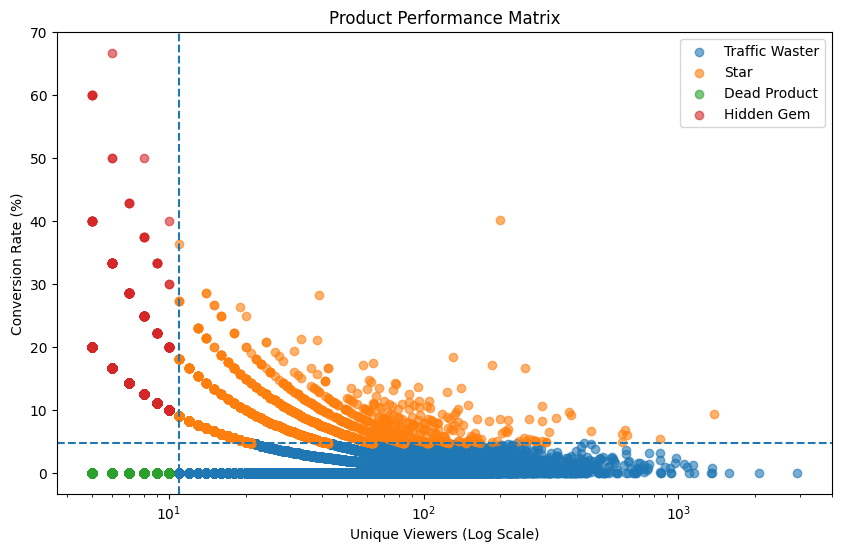

In [ ]:
plt.figure(figsize=(10, 6))

for segment in product_matrix_filtered['product_segment'].unique():

    data = product_matrix_filtered[
        product_matrix_filtered['product_segment'] == segment
    ]

    plt.scatter(
        data['unique_viewers'],
        data['conversion_rate'],
        label=segment,
        alpha=0.6
    )

plt.axvline(
    views_threshold,
    linestyle='--'
)

plt.axhline(
    conversion_threshold,
    linestyle='--'
)

plt.xscale('log')

plt.xlabel('Unique Viewers (Log Scale)')
plt.ylabel('Conversion Rate (%)')
plt.title('Product Performance Matrix')

plt.legend()

plt.show()

Hypothesis Testing

In [ ]:
user_metrics = (
    df.groupby('visitorid')
    .agg(
        total_events=('event', 'count'),
        total_views=('event', lambda x: (x == 'view').sum()),
        total_cart_additions=('event', lambda x: (x == 'addtocart').sum()),
        total_transactions=('event', lambda x: (x == 'transaction').sum())
    )
    .reset_index()
)

user_metrics.head()

,visitorid,total_events,total_views,total_cart_additions,total_transactions
0,0,3,3,0,0
1,1,1,1,0,0
2,2,8,8,0,0
3,3,1,1,0,0
4,4,1,1,0,0


In [ ]:
user_metrics['purchased'] = (
    user_metrics['total_transactions'] > 0
).astype(int)

user_metrics.head()

,visitorid,total_events,total_views,total_cart_additions,total_transactions,purchased
0,0,3,3,0,0,0
1,1,1,1,0,0,0
2,2,8,8,0,0,0
3,3,1,1,0,0,0
4,4,1,1,0,0,0


Define the hypotheses

Our hypotheses are:

H₀ (Null Hypothesis):
There is no significant difference in engagement
between users who purchase and users who do not purchase.

H₁ (Alternative Hypothesis):
There is a significant difference in engagement
between users who purchase and users who do not purchase.

In [ ]:
purchasers = user_metrics[
    user_metrics['purchased'] == 1
]['total_events']

non_purchasers = user_metrics[
    user_metrics['purchased'] == 0
]['total_events']

print("Purchasers:", len(purchasers))
print("Non-Purchasers:", len(non_purchasers))

Purchasers: 11719
Non-Purchasers: 1395861


In [ ]:
print("Average engagement of purchasers:",
      purchasers.mean())

print("Average engagement of non-purchasers:",
      non_purchasers.mean())

Average engagement of purchasers: 19.684102739141565
Average engagement of non-purchasers: 1.8092224082483859


In [ ]:
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(
    purchasers,
    non_purchasers,
    alternative='two-sided'
)

print("Test Statistic:", statistic)
print("P-value:", p_value)

Test Statistic: 15502458325.5
P-value: 0.0


In [ ]:
alpha = 0.05

if p_value < alpha:
    print(
        "Reject the Null Hypothesis: "
        "There is a statistically significant difference "
        "in engagement between purchasers and non-purchasers."
    )
else:
    print(
        "Fail to reject the Null Hypothesis: "
        "There is no statistically significant evidence "
        "of a difference in engagement between purchasers "
        "and non-purchasers."
    )

Reject the Null Hypothesis: There is a statistically significant difference in engagement between purchasers and non-purchasers.


Power BI Dashboard

In [ ]:
# Funnel and conversion metrics
sql_funnel.to_csv('funnel_analysis.csv', index=False)
sql_conversion.to_csv('conversion_analysis.csv', index=False)

# Cart abandonment
sql_cart_abandonment_rate.to_csv(
    'cart_abandonment.csv',
    index=False
)

# User behaviour segmentation
behavior_segment_summary.to_csv(
    'user_segments.csv',
    index=False
)

# Product Performance Matrix
product_matrix_filtered.to_csv(
    'product_performance.csv',
    index=False
)

# Time-based analysis
sql_hourly_purchases.to_csv(
    'hourly_purchases.csv',
    index=False
)

sql_daily_purchases.to_csv(
    'daily_purchases.csv',
    index=False
)

print("All dashboard datasets exported successfully!")

All dashboard datasets exported successfully!


In [ ]:
from google.colab import files

files.download('funnel_analysis.csv')
files.download('conversion_analysis.csv')
files.download('cart_abandonment.csv')
files.download('user_segments.csv')
files.download('product_performance.csv')
files.download('hourly_purchases.csv')
files.download('daily_purchases.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>